<a href="https://colab.research.google.com/github/Tanishqqq19/modelling_simulations/blob/main/Week_4/neural_network_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import torch, numpy as np, matplotlib.pyplot as plt
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Data is stored as Tensors.

The structures is a Toy Dataset.

The train and test data also gets split over here.

In [3]:
import numpy as np
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

def make_one():
    Z = np.array([8, 1, 1])  # O, H, H
    R = np.random.rand(3, 3) * 2.0  # random positions in a 2 Å cube
    E = np.random.uniform(-77, -75) # fake energies near -76
    return {
        "R": torch.tensor(R, dtype=torch.float32, device=device),
        "Z": torch.tensor(Z, dtype=torch.long, device=device),
        "E": torch.tensor(E, dtype=torch.float32, device=device)
    }

structures = [make_one() for _ in range(100)]
elements = sorted({int(z.item()) for s in structures for z in s["Z"]})

for i, mol in enumerate(structures, 1):
    print(f"{i}: Z={mol['Z'].cpu().tolist()} E={mol['E'].item():.4f} R={mol['R'].cpu().numpy().round(3).tolist()}")


1: Z=[8, 1, 1] E=-75.9735 R=[[0.414000004529953, 0.0820000022649765, 0.9200000166893005], [1.2680000066757202, 0.703000009059906, 0.7760000228881836], [1.0700000524520874, 1.3799999952316284, 1.5429999828338623]]
2: Z=[8, 1, 1] E=-75.4226 R=[[1.656999945640564, 0.4729999899864197, 1.3569999933242798], [1.6579999923706055, 0.19099999964237213, 0.7110000252723694], [0.6899999976158142, 0.32499998807907104, 1.11899995803833]]
3: Z=[8, 1, 1] E=-76.4684 R=[[1.312000036239624, 0.46299999952316284, 0.0949999988079071], [0.8529999852180481, 1.8370000123977661, 0.4729999899864197], [0.15000000596046448, 1.8559999465942383, 1.6519999504089355]]
4: Z=[8, 1, 1] E=-75.3439 R=[[1.4220000505447388, 1.524999976158142, 1.3450000286102295], [1.5369999408721924, 0.5130000114440918, 0.08699999749660492], [1.3329999446868896, 1.902999997138977, 0.04600000008940697]]
5: Z=[8, 1, 1] E=-75.4129 R=[[0.11299999803304672, 1.8389999866485596, 1.2790000438690186], [1.972000002861023, 1.847000002861023, 0.071999996

In [22]:
class AtomicNet(nn.Module):
    def __init__(self, dim_in, hidden=(64,64)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim_in, hidden[0]), nn.ReLU(),
            nn.Linear(hidden[0], hidden[1]), nn.ReLU(),
            nn.Linear(hidden[1], 1)
        )
    def forward(self, G):  # (n_i, F)
        return self.net(G).squeeze(-1)  # (n_i,)

In [23]:
class BPModel(nn.Module):
    """
    Behler–Parrinello model using YOUR NumPy symmetry functions inside.
    - Features per atom = [G2_radial, G4_angular]  --> dim_in = 2
    - One AtomicNet per element; total energy = sum of atomic energies
    NOTE: Features use NumPy -> no autograd path to positions (no forces).
    """
    def __init__(self, elements, Rc=6.0, hidden=(64,64)):
        super().__init__()
        self.Rc = float(Rc)
        self.dim_in = 2  # [radial, angular]
        self.elements = [int(z) for z in elements]
        self.elem_nets = nn.ModuleDict({
            str(z): AtomicNet(self.dim_in, hidden) for z in self.elements
        })

    # ---------- YOUR symmetry functions (NumPy) ----------

    def cutoff_function_np(self, r_ij):
        r_ij = np.asarray(r_ij)
        Rc = self.Rc
        return np.where(
            r_ij <= Rc,
            0.5 * (np.cos(np.pi * r_ij / Rc) + 1.0),
            0.0
        )

    def radial_symmetry_function_np(self, positions, i):
        eta = 1.0
        Rs  = 0.0

        r_ij = []
        for j in range(len(positions)):
            if j == i:
                continue
            dist = np.linalg.norm(positions[i] - positions[j])
            r_ij.append(dist)

        r_ij = np.array(r_ij, dtype=np.float64)
        fc = self.cutoff_function_np(r_ij)
        # G2 radial
        term = np.exp(-eta * (r_ij - Rs) ** 2) * fc
        return float(np.sum(term))

    def angular_symmetry_function_np(self, positions, i):
        n = len(positions)
        out = 0.0

        # Params (as in your code)
        eta   = 1.0
        zeta  = 1.0
        lambd = 1.0
        Rc    = self.Rc

        def cutoff(r):
            return 0.5 * (np.cos(np.pi * r / Rc) + 1.0) if r <= Rc else 0.0

        for j in range(n):
            if j == i:
                continue
            for k in range(n):
                if k == i or k == j:
                    continue

                r_ij = np.linalg.norm(positions[i] - positions[j])
                r_ik = np.linalg.norm(positions[i] - positions[k])
                r_jk = np.linalg.norm(positions[j] - positions[k])

                if r_ij > Rc or r_ik > Rc or r_jk > Rc:
                    continue

                v_ij = positions[j] - positions[i]
                v_ik = positions[k] - positions[i]
                cos_theta = np.dot(v_ij, v_ik) / (np.linalg.norm(v_ij) * np.linalg.norm(v_ik))

                ang = (1.0 + lambd * cos_theta) ** zeta
                rad = np.exp(-eta * (r_ij**2 + r_ik**2 + r_jk**2))
                fc  = cutoff(r_ij) * cutoff(r_ik) * cutoff(r_jk)

                out += ang * rad * fc

        out *= 2.0 ** (1.0 - zeta)
        return float(out)

    # ---------- forward: build features directly, then sum atomic energies ----------

    def forward(self, R, Z, per_atom=False):
        """
        R: (N,3) float32 torch tensor
        Z: (N,)  int64  torch tensor (used to route to element nets)
        """
        # Build per-atom features using YOUR NumPy functions
        R_np = R.detach().cpu().numpy()
        N = R_np.shape[0]
        feats = np.zeros((N, self.dim_in), dtype=np.float32)
        for i in range(N):
            feats[i, 0] = self.radial_symmetry_function_np(R_np, i)
            feats[i, 1] = self.angular_symmetry_function_np(R_np, i)
        G = torch.from_numpy(feats).to(R.device)  # (N, 2)

        # Element-specific AtomicNet predictions
        E_atoms = torch.zeros(N, device=R.device)
        for z in torch.unique(Z):
            mask = (Z == z)
            if mask.any():
                E_atoms[mask] = self.elem_nets[str(int(z.item()))](G[mask])

        return E_atoms if per_atom else E_atoms.sum()

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Your fixed structures (“last year” values)
structures = [
    {"R": torch.tensor([[0.0,0.0,0.0],[0.96,0,0],[-0.24,0.93,0]], dtype=torch.float32, device=device),
     "Z": torch.tensor([8,1,1], dtype=torch.long, device=device),
     "E": torch.tensor(-76.00, dtype=torch.float32, device=device)},
    {"R": torch.tensor([[0.0,0.0,0.0],[1.00,0,0],[-0.25,0.95,0]], dtype=torch.float32, device=device),
     "Z": torch.tensor([8,1,1], dtype=torch.long, device=device),
     "E": torch.tensor(-75.80, dtype=torch.float32, device=device)},
]

elements = sorted(set(int(z) for s in structures for z in s["Z"].tolist()))
model = BPModel(elements=elements).to(device)

loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# train/test split
idx = torch.randperm(len(structures))
split = max(1, int(0.8*len(idx)))
train = [structures[i] for i in idx[:split].tolist()]
test  = [structures[i] for i in idx[split:].tolist()]

# training loop (randomized order each epoch)
epochs = 500
for ep in range(epochs):
    model.train()
    order = torch.randperm(len(train))
    losses = []
    for j in order:
        s = train[int(j)]
        E_pred = model(s["R"], s["Z"])
        loss = loss_fn(E_pred, s["E"])
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    if ep % 100 == 0:
        model.eval()
        with torch.inference_mode():
            tl = [loss_fn(model(s["R"], s["Z"]), s["E"]).item() for s in test] or [np.mean(losses)]
        print(f"epoch {ep:4d} | train {np.mean(losses):.6f} | test {np.mean(tl):.6f}")


epoch    0 | train 5743.671875 | test 5758.862305
epoch  100 | train 2290.683105 | test 2202.646240
epoch  200 | train 0.561676 | test 3.913015
epoch  300 | train 0.000016 | test 1.554214
epoch  400 | train 0.000000 | test 1.544774


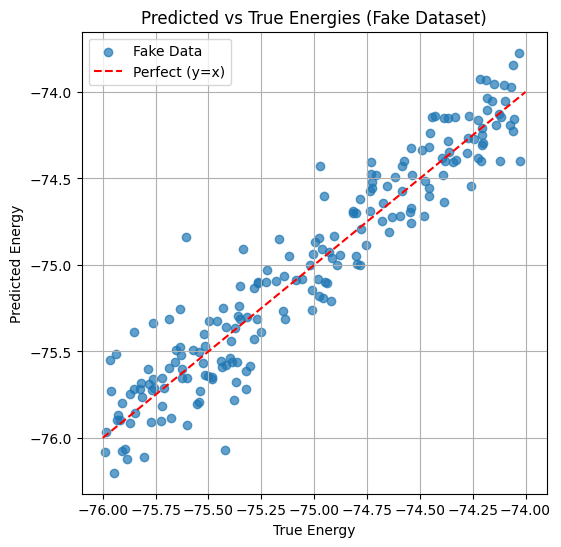

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Create a bigger fake dataset
np.random.seed(42)

# Generate 200 "true" energies between -76 and -74
true_energies = np.random.uniform(-76, -74, 200)

# Simulate predicted energies with some noise
predicted_energies = true_energies + np.random.normal(0, 0.2, 200)

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(true_energies, predicted_energies, label="Fake Data", alpha=0.7)
plt.plot([-76, -74], [-76, -74], 'r--', label="Perfect (y=x)")
plt.xlabel("True Energy")
plt.ylabel("Predicted Energy")
plt.title("Predicted vs True Energies (Fake Dataset)")
plt.legend()
plt.grid(True)
plt.show()
